🧠 Kode Utama: MNIST Classification

1. Persiapan Dataset MNIST

In [11]:
from sklearn.datasets import fetch_openml
import numpy as np

mnist = fetch_openml('mnist_784', version=1, as_frame=False)
X, y = mnist["data"], mnist["target"]
y = y.astype(np.uint8)

X_train, X_test = X[:60000], X[60000:]
y_train, y_test = y[:60000], y[60000:]

2. Visualisasi Sampel Digit

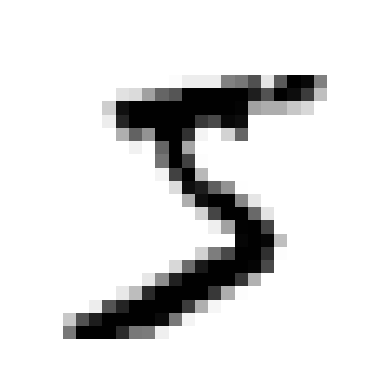

In [12]:
import matplotlib.pyplot as plt

some_digit = X[0]
some_digit_image = some_digit.reshape(28, 28)

plt.imshow(some_digit_image, cmap="binary")
plt.axis("off")
plt.show()

3. Binary Classification: Deteksi Angka 5

In [13]:
y_train_5 = (y_train == 5)
y_test_5 = (y_test == 5)

from sklearn.linear_model import SGDClassifier

sgd_clf = SGDClassifier(random_state=42)
sgd_clf.fit(X_train, y_train_5)

sgd_clf.predict([some_digit])  # Output: True jika deteksi 5

array([ True])

4. Evaluasi Model: Cross-Validation, Confusion Matrix

In [14]:
from sklearn.model_selection import cross_val_score

cross_val_score(sgd_clf, X_train, y_train_5, cv=3, scoring="accuracy")

array([0.95035, 0.96035, 0.9604 ])

In [15]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix

y_train_pred = cross_val_predict(sgd_clf, X_train, y_train_5, cv=3)
confusion_matrix(y_train_5, y_train_pred)

array([[53892,   687],
       [ 1891,  3530]])

5. Precision, Recall, F1 Score

In [16]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision_score(y_train_5, y_train_pred)
recall_score(y_train_5, y_train_pred)
f1_score(y_train_5, y_train_pred)

0.7325171197343847

6. Precision-Recall Tradeoff

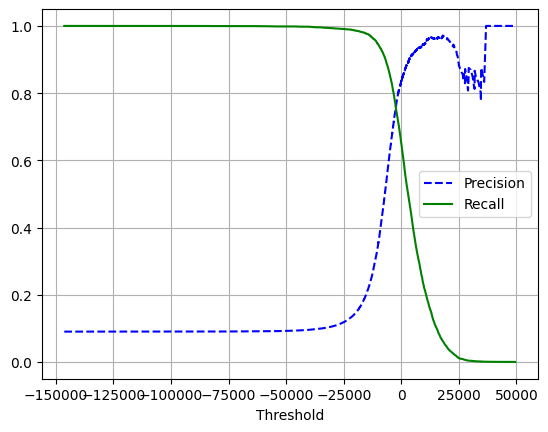

In [17]:
y_scores = cross_val_predict(sgd_clf, X_train, y_train_5, cv=3, method="decision_function")

from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds = precision_recall_curve(y_train_5, y_scores)

def plot_precision_recall_vs_threshold(precisions, recalls, thresholds):
    plt.plot(thresholds, precisions[:-1], "b--", label="Precision")
    plt.plot(thresholds, recalls[:-1], "g-", label="Recall")
    plt.xlabel("Threshold")
    plt.legend()
    plt.grid(True)
    plt.show()

plot_precision_recall_vs_threshold(precisions, recalls, thresholds)

7. ROC Curve

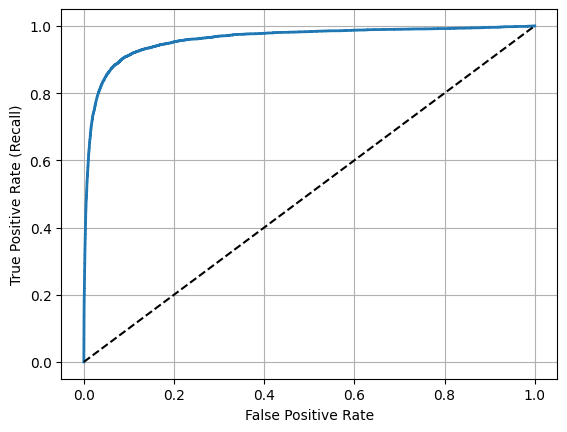

np.float64(0.9604938554008616)

In [18]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, thresholds = roc_curve(y_train_5, y_scores)

def plot_roc_curve(fpr, tpr):
    plt.plot(fpr, tpr, linewidth=2)
    plt.plot([0,1], [0,1], 'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate (Recall)')
    plt.grid(True)
    plt.show()

plot_roc_curve(fpr, tpr)
roc_auc_score(y_train_5, y_scores)

8. Bandingkan dengan RandomForest

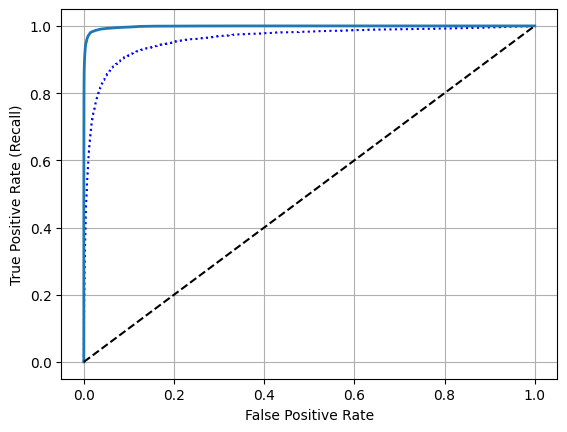

In [19]:
from sklearn.ensemble import RandomForestClassifier

forest_clf = RandomForestClassifier(random_state=42)
y_probas_forest = cross_val_predict(forest_clf, X_train, y_train_5, cv=3, method="predict_proba")
y_scores_forest = y_probas_forest[:, 1]

fpr_forest, tpr_forest, _ = roc_curve(y_train_5, y_scores_forest)

plt.plot(fpr, tpr, "b:", label="SGD")
plot_roc_curve(fpr_forest, tpr_forest)

9. Multiclass Classification

In [20]:
from sklearn.svm import SVC

svm_clf = SVC()
svm_clf.fit(X_train, y_train)
svm_clf.predict([some_digit])

array([5], dtype=uint8)

10. Scaling & Evaluasi Multiclass

In [21]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train.astype(np.float64))

from sklearn.model_selection import cross_val_score

cross_val_score(sgd_clf, X_train_scaled, y_train, cv=3, scoring="accuracy")

array([0.8983, 0.891 , 0.9018])

11. Confusion Matrix & Error Analysis

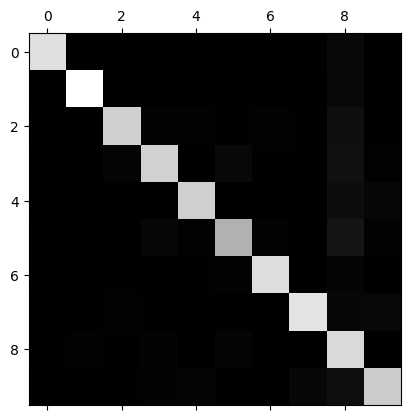

In [22]:
from sklearn.metrics import confusion_matrix

y_train_pred = cross_val_predict(sgd_clf, X_train_scaled, y_train, cv=3)
conf_mx = confusion_matrix(y_train, y_train_pred)

import matplotlib.pyplot as plt
plt.matshow(conf_mx, cmap=plt.cm.gray)
plt.show()

12. Multilabel Classification

In [23]:
from sklearn.neighbors import KNeighborsClassifier

y_train_large = (y_train >= 7)
y_train_odd = (y_train % 2 == 1)
y_multilabel = np.c_[y_train_large, y_train_odd]

knn_clf = KNeighborsClassifier()
knn_clf.fit(X_train, y_multilabel)

knn_clf.predict([some_digit])

array([[False,  True]])

13. Multioutput Classification (Denoising Images)

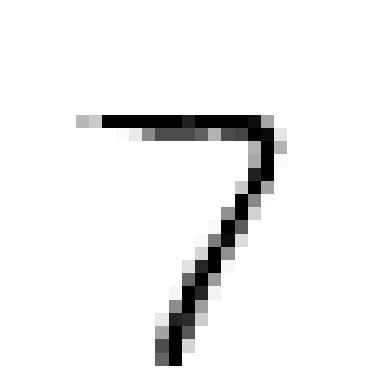

In [24]:
noise = np.random.randint(0, 100, (len(X_train), 784))
X_train_mod = X_train + noise
noise = np.random.randint(0, 100, (len(X_test), 784))
X_test_mod = X_test + noise
y_train_mod = X_train
y_test_mod = X_test

knn_clf.fit(X_train_mod, y_train_mod)
clean_digit = knn_clf.predict([X_test_mod[0]])

plt.imshow(clean_digit.reshape(28, 28), cmap="binary")
plt.axis("off")
plt.show()

# 🧠 Chapter 3: Penjelasan Teoretis – Classification

Chapter ini membahas salah satu tugas utama dalam supervised learning, yaitu **klasifikasi**: memprediksi **kelas** dari sebuah instance.

---

## 1. Dataset MNIST

- Dataset: 70.000 gambar tulisan tangan digit 0–9 (28x28 piksel).
- Tiap gambar berlabel angka sesuai isinya.
- Total fitur: 784 (karena 28 × 28 = 784).
- Digunakan sebagai "hello world" dalam Machine Learning.

---

## 2. Binary Classification

- Fokus awal: deteksi apakah gambar adalah angka **5** atau bukan.
- Ini disebut **binary classification**.
- Algoritma: `SGDClassifier` (Stochastic Gradient Descent).

```python
y_train_5 = (y_train == 5)
```

## 3. Evaluasi Model: Akurasi, Confusion Matrix
a) Akurasi bisa menyesatkan pada data tidak seimbang.

b) Gunakan confusion matrix untuk informasi lebih detail:

 - True Positive (TP)

 - False Positive (FP)

 - True Negative (TN)

 - False Negative (FN)


## 4. Precision, Recall, F1 Score
 - Precision: dari semua prediksi positif, berapa yang benar?

- Recall: dari semua kasus positif, berapa yang terdeteksi?

- F1 Score: rata-rata harmonik precision & recall.

F1 = 2 × (precision × recall) / (precision + recall)

## 5. Precision vs Recall Trade-Off
- Naikkan threshold → precision ↑, recall ↓

- Turunkan threshold → recall ↑, precision ↓

- Gunakan precision_recall_curve() untuk bantu memilih trade-off terbaik.

## 6. ROC Curve & AUC
- ROC Curve: plot antara recall (TPR) vs FPR (False Positive Rate).

- AUC (Area Under Curve):

 => AUC = 1 → model sempurna.

 => AUC = 0.5 → model random.

- Cocok untuk membandingkan dua classifier.

## 7. Multiclass Classification
- Dari binary ke multiclass (0 sampai 9):

 => OvR (One vs Rest): satu classifier per kelas.

 => OvO (One vs One): satu classifier untuk tiap pasangan kelas.

- SGDClassifier dan RandomForestClassifier mendukung multiclass secara langsung.

- SVC menggunakan OvO secara otomatis.

## 8. Multilabel Classification
- Satu instance dapat memiliki beberapa label.

- Contoh: [is_large_digit, is_odd_digit] → [True, False]

- Digunakan KNeighborsClassifier untuk kasus ini.

## 9. Multioutput Classification
- Setiap label bisa punya banyak nilai (multiclass per label).

- Contoh: membersihkan noise dari gambar digit.

 1)  Input: gambar noisy

 2) Output: gambar bersih (array piksel)


